# Customer Behavior Segmentation for Retail Optimization
- You are working as a Data Scientist in an e-commerce company.
- The company has collected detailed customer behavior data, including:
    - Annual Income
    - Spending Score
    - Purchase Frequency
    - Average Basket Value
    - Website Visit Time
    - Discount Usage Rate
    - Product Category Preferences
    - Return Rate

- The dataset contains multiple numerical features, making it difficult to:
    - Visualize customer groups
    - Train clustering models efficiently
    - Understand key behavioral patterns
- Dataset Name:
    Customer Personality Analysis

---------------------------------------------------

- 🔹 Part 1 – Data Preparation
    1. Load the dataset.
    2. Select only numerical features relevant to customer behavior.
    3. Handle missing values.
    4. Standardize the data.
- 🔹 Part 2 – PCA Implementation
    1. Apply PCA on the standardized dataset.
    6. Plot the explained variance ratio.
    7. Determine:
        - How many principal components are needed to retain at least 90% of total variance?
    8. Reduce the dataset to those components.
- 🔹 Part 3 – Interpretation
    1. Identify:
        - Which original features contribute most to PC1?
        - Which features dominate PC2?
    10. Explain what PC1 and PC2 represent in business terms.
- 🔹 Part 4 – Practical Application
    1. Visualize customers in 2D PCA space.
    12. Now apply K-Means clustering on:
        - Original dataset
        - PCA-reduced dataset
    13. Compare:
        - Silhouette score
        - Computation time
        - Cluster separation quality

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

df = pd.read_csv("marketing_campaign.csv", sep="\t")

In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [11]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

2️⃣ Select numerical behaviour features

In [ ]:
# Convert Year_Birth → Age
df["Age"] = 2026 - df["Year_Birth"]

# Convert date to numeric behaviour
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Customer_Days"] = (pd.Timestamp("2026-01-01") - df["Dt_Customer"]).dt.days

# Drop non-numeric or useless columns
drop_cols = [
    "ID","Education","Marital_Status",
    "Dt_Customer","Year_Birth",
    "Z_CostContact","Z_Revenue"
]

df = df.drop(columns=drop_cols, errors="ignore")


3️⃣ Handle missing values

In [13]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [15]:
df.isnull().sum()

Income                 0
Kidhome                0
Teenhome               0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
Age                    0
Customer_Days          0
dtype: int64

4️⃣ Standardize data (MANDATORY before PCA & KMeans)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


5️⃣ Apply PCA

In [17]:
from sklearn.decomposition import PCA

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)


6️⃣ Plot Explained Variance Ratio

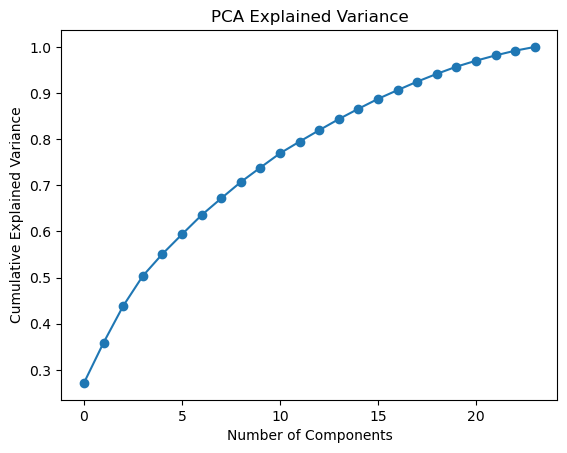

In [18]:
plt.figure()
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


7️⃣ Components needed for ≥90% variance

In [19]:
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cum_var >= 0.90) + 1

print("Components needed for 90% variance:", n_components_90)


Components needed for 90% variance: 17


8️⃣ Reduce dataset

In [20]:
pca = PCA(n_components=n_components_90)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)


Original shape: (2240, 24)
Reduced shape: (2240, 17)


9️⃣ Feature contributions to PCs

In [21]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns
)

# Top contributors
pc1_top = loadings.iloc[0].abs().sort_values(ascending=False).head(5)
pc2_top = loadings.iloc[1].abs().sort_values(ascending=False).head(5)

print("Top PC1 Features:\n", pc1_top)
print("\nTop PC2 Features:\n", pc2_top)


Top PC1 Features:
 NumCatalogPurchases    0.318570
MntMeatProducts        0.312283
MntWines               0.306947
Income                 0.290108
NumStorePurchases      0.282980
Name: 0, dtype: float64

Top PC2 Features:
 NumDealsPurchases    0.491506
Teenhome             0.480489
NumWebPurchases      0.368135
Customer_Days        0.272246
Age                  0.269400
Name: 1, dtype: float64


11️⃣ Visualize customers in 2D PCA space

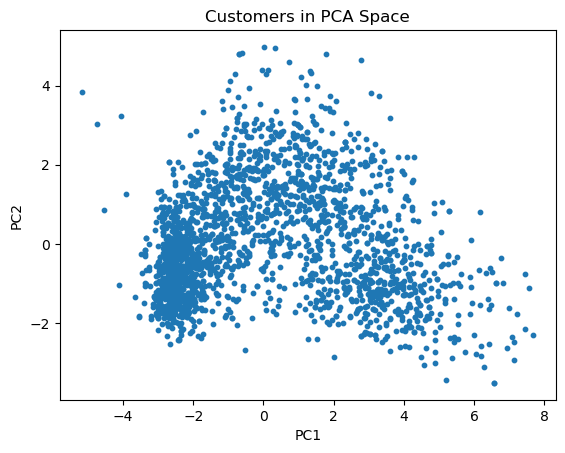

In [22]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customers in PCA Space")
plt.show()


12️⃣ Apply K-Means

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

start = time.time()

kmeans_orig = KMeans(n_clusters=4, random_state=42)
labels_orig = kmeans_orig.fit_predict(X_scaled)

time_orig = time.time() - start

sil_orig = silhouette_score(X_scaled, labels_orig)


c:\Users\rakes\anaconda31\envs\Himaenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


In [24]:
start = time.time()

kmeans_pca = KMeans(n_clusters=4, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

time_pca = time.time() - start

sil_pca = silhouette_score(X_pca, labels_pca)


c:\Users\rakes\anaconda31\envs\Himaenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


13️⃣

In [25]:
print("\n--- Comparison ---")
print("Silhouette (Original):", sil_orig)
print("Silhouette (PCA):", sil_pca)

print("\nComputation Time (Original):", round(time_orig,4),"sec")
print("Computation Time (PCA):", round(time_pca,4),"sec")



--- Comparison ---
Silhouette (Original): 0.18087421718909374
Silhouette (PCA): 0.1998298900576255

Computation Time (Original): 3.7143 sec
Computation Time (PCA): 0.0179 sec
